### import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraried imported sucessfully')

Libraried imported sucessfully


### Load Data

In [2]:
df = pd.read_csv(r'../Data/diabetes.csv')
print('Shape of Dataset:', df.shape)
df.head()

Shape of Dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Basic Info

In [3]:
print('\n===Dataset info===')
df.info()

print('\n===Missing values===')
print(df.isnull().sum())

print('\n===Statistical summary===')
df.describe(include='all')


===Dataset info===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

===Missing values===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFu

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


- Pregnancies — how many times the patient was pregnant
- Glucose — blood sugar level (most important feature!)
- BloodPressure — diastolic blood pressure (mm Hg)
- SkinThickness — triceps skin fold thickness (mm)
- Insulin — 2-hour serum insulin level
- BMI — body mass index (weight relative to height)
- DiabetesPedigreeFunction — how likely based on family history
- Age — age of patient
- Outcome — 0 = no diabetes, 1 = diabetes (this is what we predict)

### Check Target Columns


===Target Distribution===
Outcome
0    500
1    268
Name: count, dtype: int64


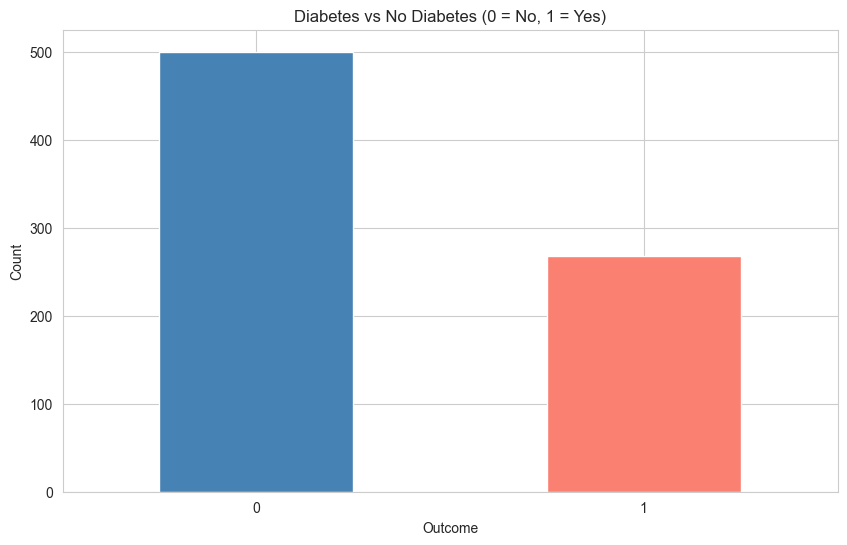

In [4]:
print('\n===Target Distribution===')
print(df['Outcome'].value_counts())

#Plot it
df['Outcome'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Diabetes vs No Diabetes (0 = No, 1 = Yes)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Finding Hidden Zero Values

In [5]:
#These columns cannot be zero in biologically

zero_check_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for cols in zero_check_cols:
    zero_count = (df[cols]==0).sum()
    percentage = (zero_count / len(df)) * 100

    print(f"{cols}: {zero_count} zeros ({percentage:.1f}%)")

Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


In [6]:
df_cleaned = df.copy()

df_cleaned[zero_check_cols] = df_cleaned[zero_check_cols].replace(0, np.nan)

print('===Missing Values After Fixing===')
print(df_cleaned.isnull().sum())

===Missing Values After Fixing===
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [7]:
for cols in zero_check_cols:
    df_cleaned[cols] = df_cleaned.groupby('Outcome')[cols].transform(
        lambda x: x.fillna(x.median())
    )

print('===Missing values After Filling ===')
print(df_cleaned.isnull().sum())
print('\nData is clean now!')

===Missing values After Filling ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Data is clean now!


In [8]:
print('===Duplicated Rows===')
print('Number of duplicates: ',df_cleaned.duplicated().sum())

df_cleaned.duplicated()

===Duplicated Rows===
Number of duplicates:  0


0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool

In [9]:
print('===Median Insulin by Group===')
print(df_cleaned.groupby('Outcome')['Insulin'].median())

print('===Medinan Glucose by Group===')
print(df_cleaned.groupby('Outcome')['Glucose'].median())

===Median Insulin by Group===
Outcome
0    102.5
1    169.5
Name: Insulin, dtype: float64
===Medinan Glucose by Group===
Outcome
0    107.0
1    140.0
Name: Glucose, dtype: float64


In [10]:
# Check how many patients have BMI above 50
print("BMI above 50:", (df_cleaned['BMI'] > 50).sum())
print("BMI above 45:", (df_cleaned['BMI'] > 45).sum())

BMI above 50: 8
BMI above 45: 35


In [11]:
# Cap SkinThickness at 60 (medical maximum)
df_cleaned['SkinThickness'] = df_cleaned['SkinThickness'].clip(upper=60)
print("New Max SkinThickness:", df_cleaned['SkinThickness'].max())

# Confirm no more violations
above_60 = (df_cleaned['SkinThickness'] > 60).sum()
print("Patients above 60:", above_60)

New Max SkinThickness: 60.0
Patients above 60: 0


In [13]:
print('Infulin', (df_cleaned['Insulin']>514).sum())

Infulin 8


In [14]:
df_cleaned['Insulin'] = df_cleaned['Insulin'].clip(lower=14, upper=514)
print('Insulin Min: ', df_cleaned['Insulin'].min())
print('Insulin Max:', df_cleaned['Insulin'].max())


Insulin Min:  14.0
Insulin Max: 514.0


In [15]:
print("Below 14:", (df_cleaned['Insulin'] < 14).sum())
print("Above 514:", (df_cleaned['Insulin'] > 514).sum())

Below 14: 0
Above 514: 0


In [16]:
df_cleaned['BMI'] = df_cleaned['BMI'].clip(lower=15, upper=60)

In [17]:
print("=== FINAL DATA QUALITY CHECK ===\n")
ranges = {
    'Pregnancies':             (0,  20),
    'Glucose':                 (44, 200),
    'BloodPressure':           (24, 122),
    'SkinThickness':           (7,  60),
    'Insulin':                 (14, 514),
    'BMI':                     (15, 60),
    'DiabetesPedigreeFunction':(0.07, 2.5),
    'Age':                     (18, 81)
}

for col, (min_val, max_val) in ranges.items():
    below_min = (df_cleaned[col] < min_val).sum()
    above_max = (df_cleaned[col] > max_val).sum()
    
    if below_min > 0 or above_max > 0:
        print(f"{col}: Issues found!")
    else:
        print(f"{col}: Clean")


=== FINAL DATA QUALITY CHECK ===

Pregnancies: Clean
Glucose: Clean
BloodPressure: Clean
SkinThickness: Clean
Insulin: Clean
BMI: Clean
DiabetesPedigreeFunction: Clean
Age: Clean


In [18]:
df_cleaned.to_csv('../Data/diabetes_cleaned.csv', index=False)
print('Cleaned data saved to ../Data/diabetes_cleaned.csv')

# Heatmap Plot

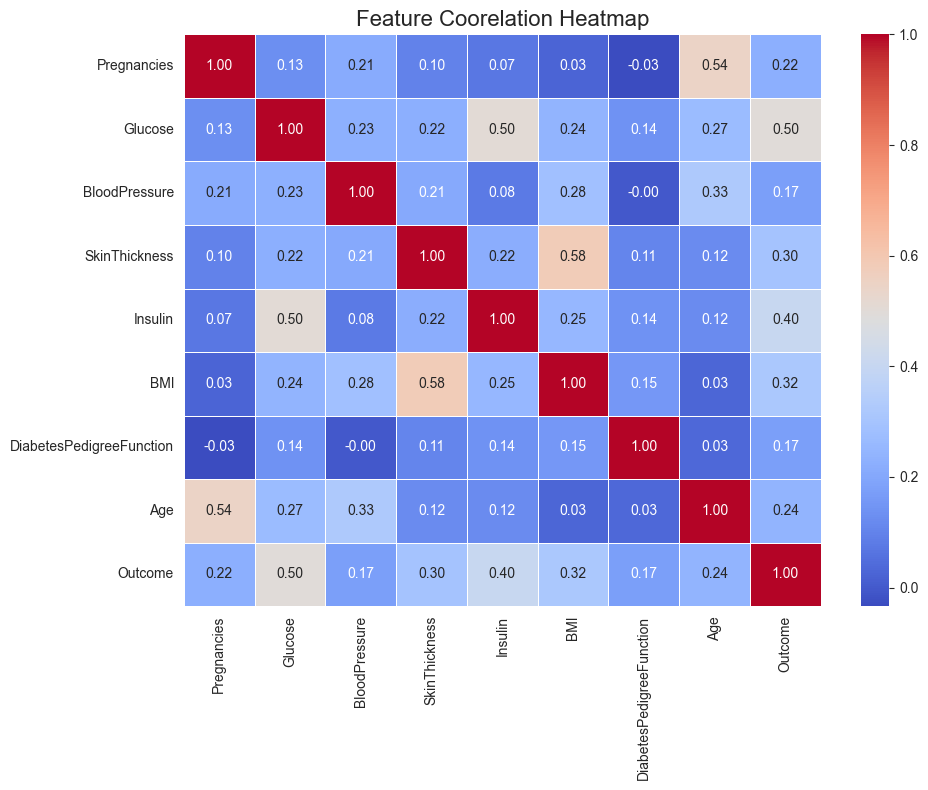

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df_cleaned.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Feature Coorelation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Distribution Plot

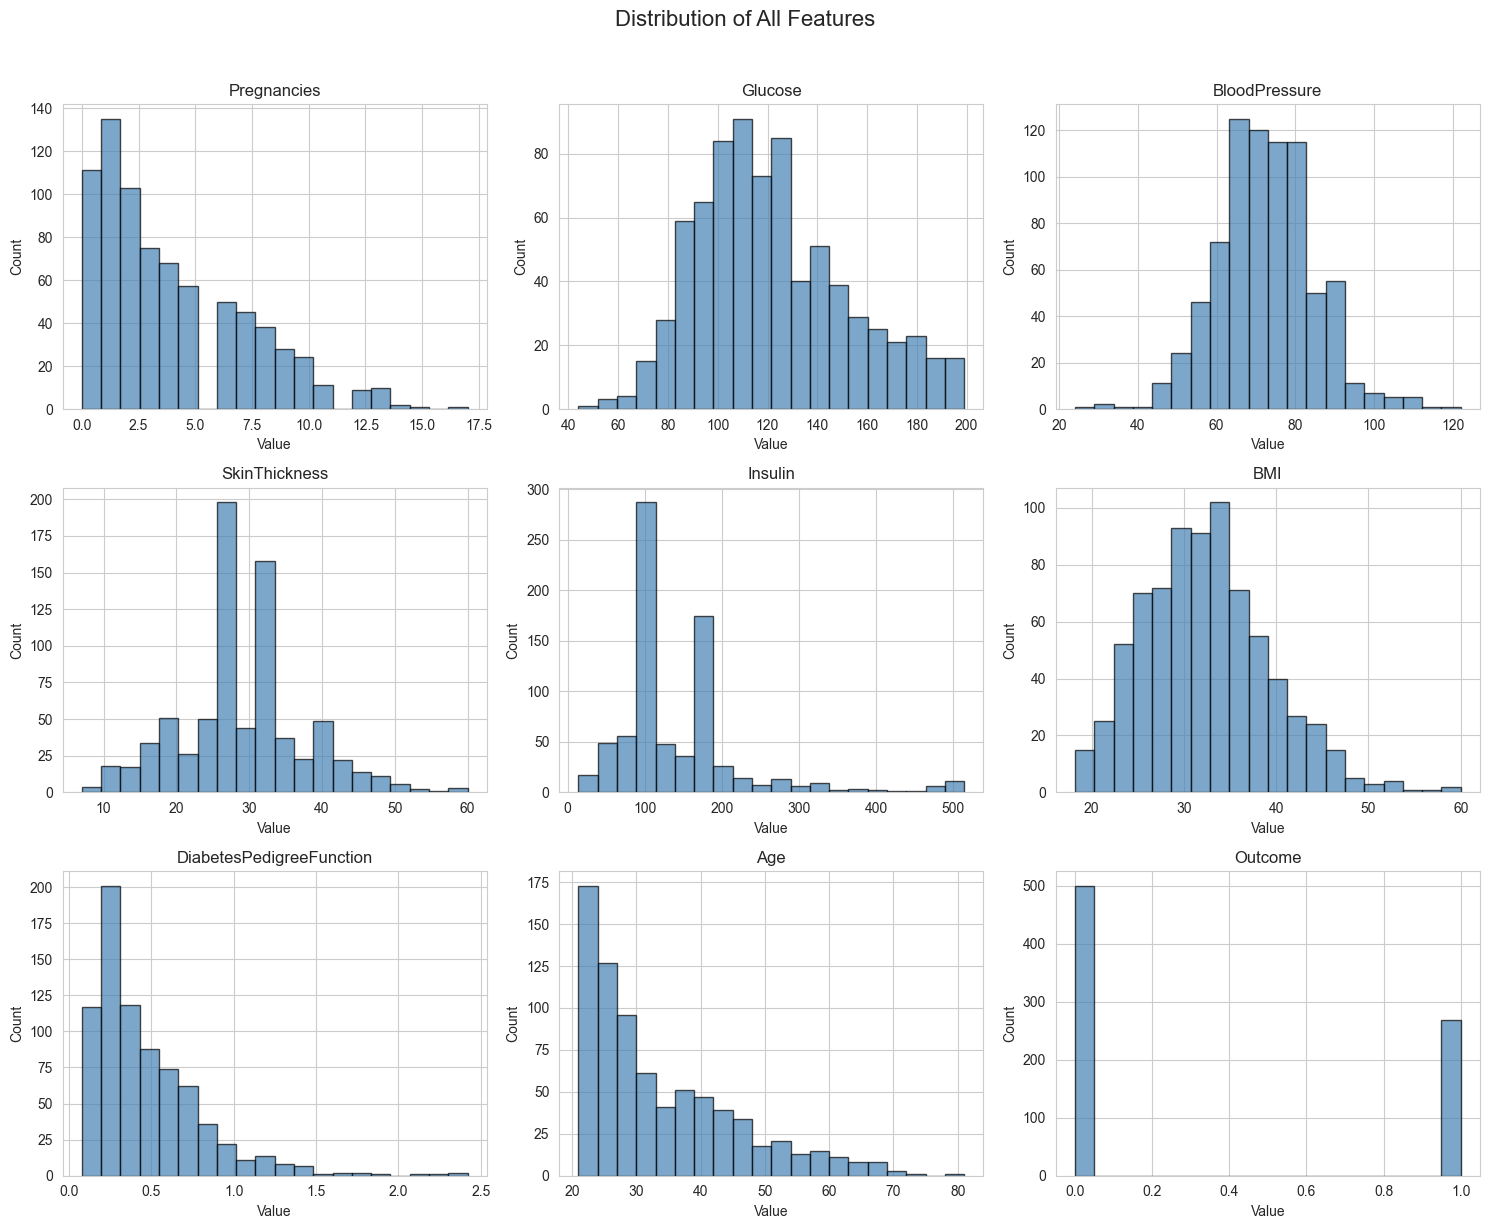

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

for i, col in enumerate(features):
    axes[i].hist(df_cleaned[col], bins=20,
                color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of All Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

- Right Skewed      → 🚨 Needs attention!
- Nearly Normal     → ✅ Perfect, no change needed
- Bimodal           → ⚠️ Interesting, monitor
- Special (Outcome) → ✅ Expected, no change needed

# KDE - Kernal Density Estimation 

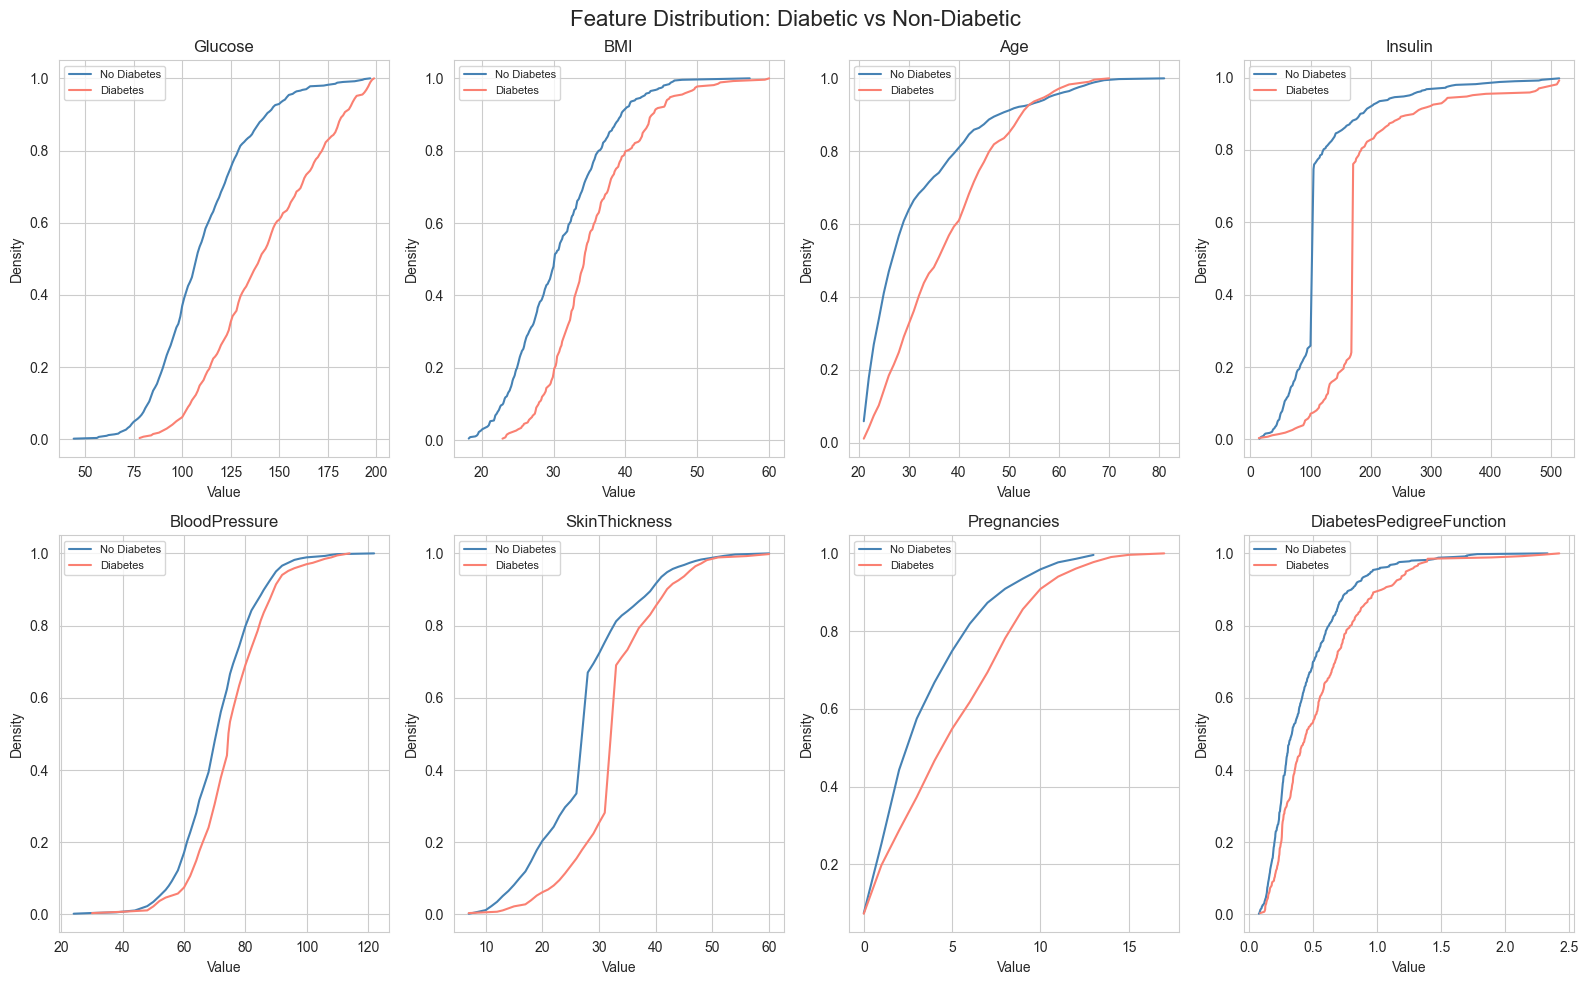

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(16,10))
axes = axes.flatten()

features = ['Glucose', 'BMI', 'Age', 'Insulin', 
            'BloodPressure', 'SkinThickness', 
            'Pregnancies', 'DiabetesPedigreeFunction']

for i, col in enumerate(features):
    axes[i].plot(df_cleaned[df_cleaned['Outcome']==0][col]\
            .sort_values(),
            df_cleaned[df_cleaned['Outcome']==0][col]\
            .sort_values().rank(pct=True),
            color='steelblue', label='No Diabetes')

    axes[i].plot(df_cleaned[df_cleaned['Outcome']==1][col]\
            .sort_values(),
            df_cleaned[df_cleaned['Outcome']==1][col]\
            .sort_values().rank(pct=True),
            color='salmon', label='Diabetes')
    axes[i].set_title(col, fontsize=12)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distribution: Diabetic vs Non-Diabetic', fontsize=16)
plt.tight_layout()
plt.show()

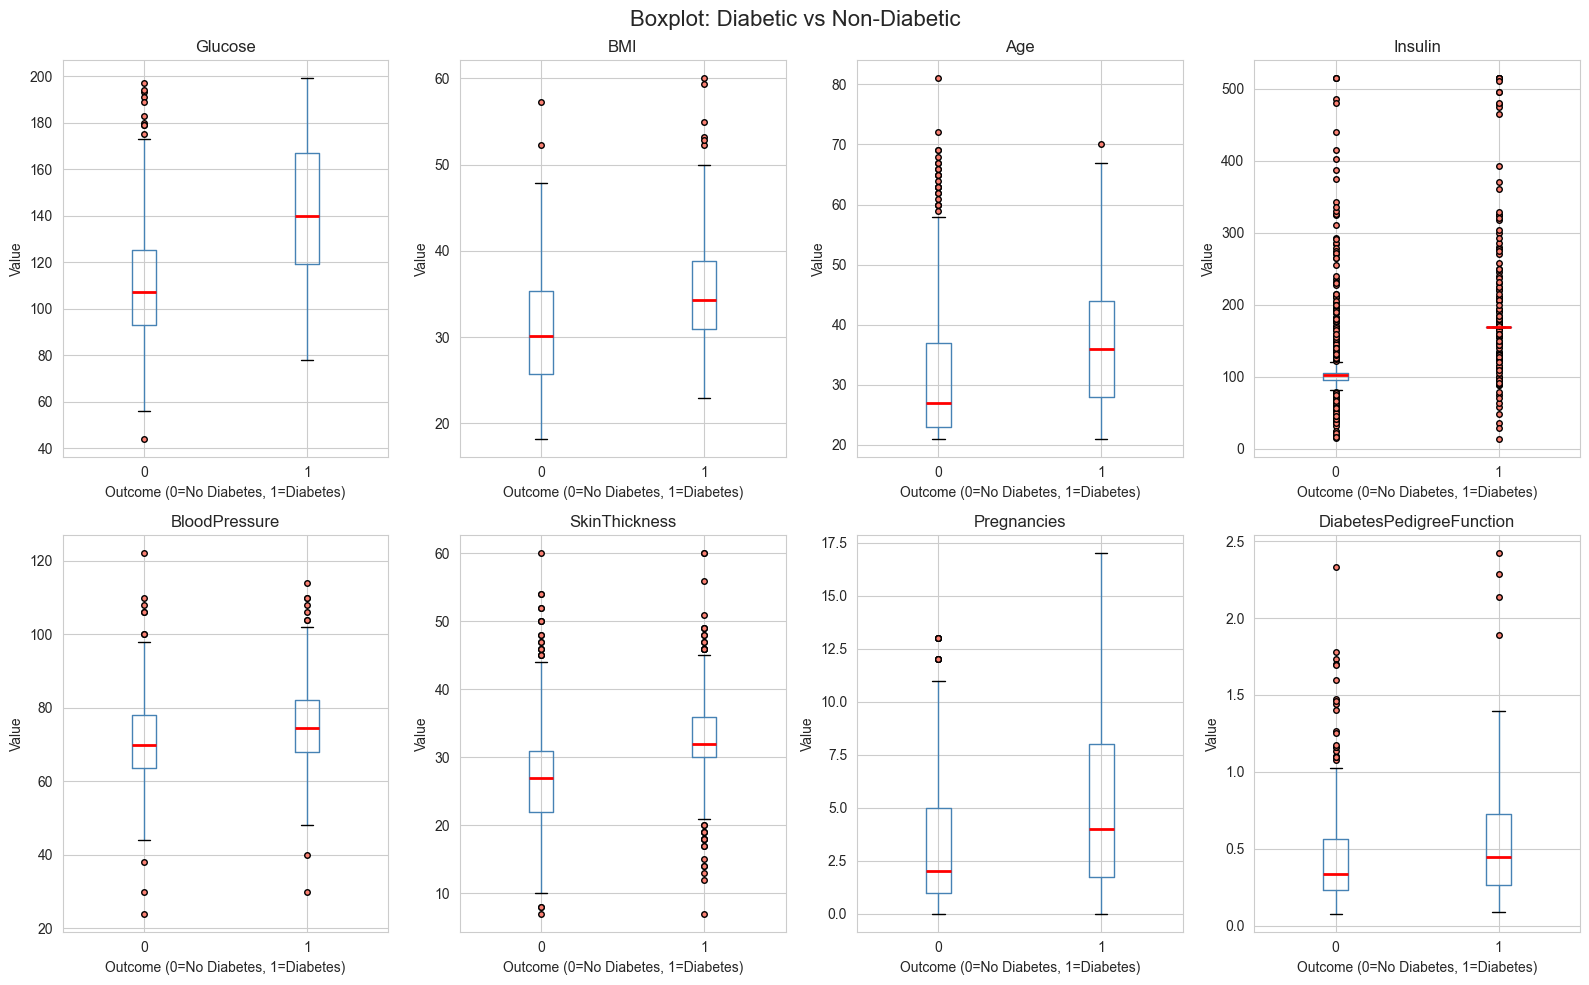

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

features = ['Glucose', 'BMI', 'Age', 'Insulin',
            'BloodPressure', 'SkinThickness',
            'Pregnancies', 'DiabetesPedigreeFunction']

for i, col in enumerate(features):
    df_cleaned.boxplot(column=col, by='Outcome', 
                      ax=axes[i], 
                      boxprops=dict(color='steelblue'),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='steelblue'),
                      flierprops=dict(marker='o', 
                                    markerfacecolor='salmon',
                                    markersize=4))
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
    axes[i].set_ylabel('Value')

plt.suptitle("Boxplot: Diabetic vs Non-Diabetic", fontsize=16)
plt.tight_layout()
plt.show()

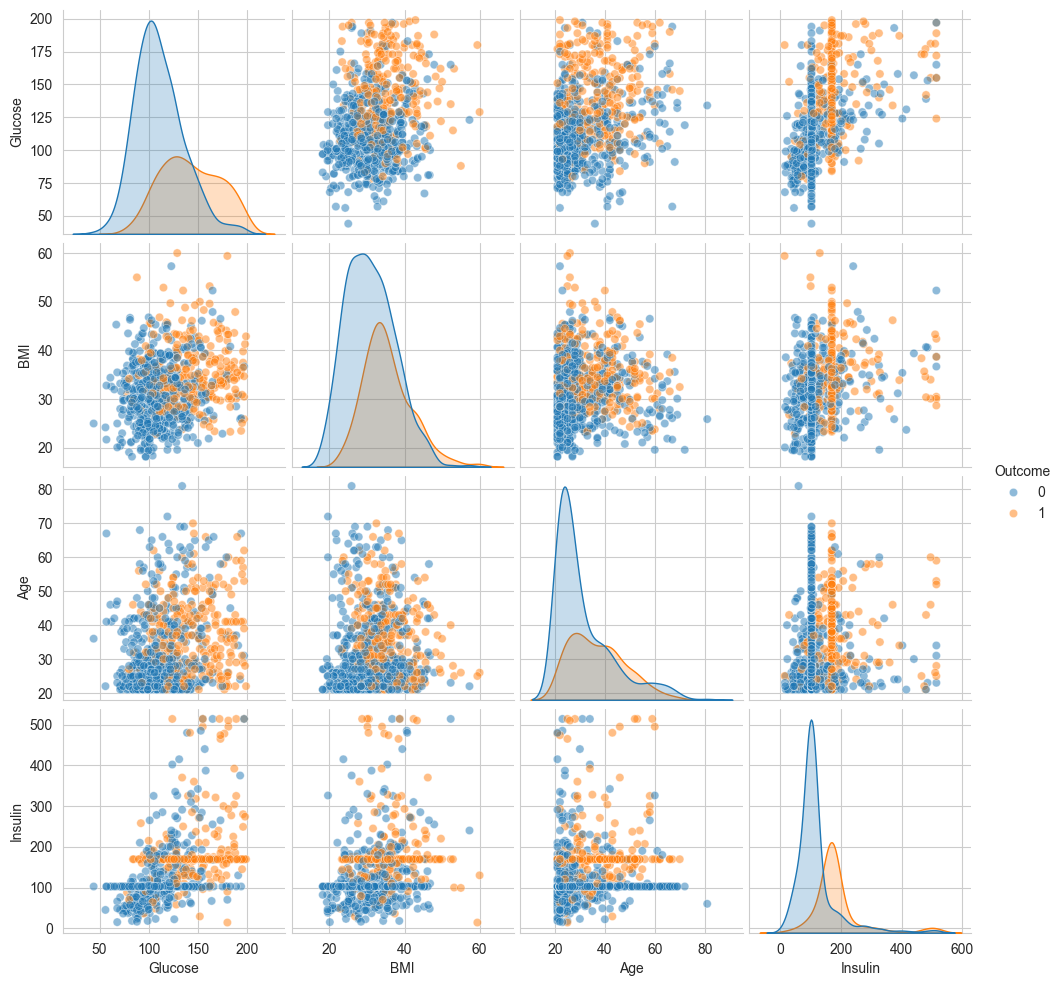

In [28]:
sns.pairplot(df_cleaned, hue='Outcome', 
             vars=['Glucose', 'BMI', 'Age', 'Insulin'],
             plot_kws={'alpha': 0.5})
plt.show()